In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import flamedisx as fd

2026-06-15 08:50:15.664186: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/global/cfs/cdirs/lz/users/rory_m/.conda/envs/flamedisx_revamped/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/global/cfs/cdirs/lz/users/rory_m/.conda/envs/flamedisx_revamped/lib/python3.11/site-packages/wimprates/__init__.py:6: UserWarning: Default WIMP parameters are changed in accordance with https://arxiv.org/abs/2105.00599 (github.com/JelleAalbers/wimprates/pull/14)
  warnings.warn(
W0000 00:00:1781538661.636007  850358 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure

In [2]:
with open('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/WIMP_discovery/outputs/early_june_outputs/accidentals/0.1_LNGS_10GeV_updated/60t_350ty/toy_data_SB.pkl', 'rb') as file:
    data = pickle.load(file)

print(len(data))
print(type(data))

1
<class 'dict'>


In [3]:
data

{10.46261568436861: [             cS1  log10_cS2        radius   source
  0       5.195979   3.721575   5473.740097     Kr85
  1      33.932372   3.958425  20494.649640    Xe136
  2       5.854143   3.766236  20603.071396  SolarER
  3      36.459969   3.897823  16872.811839     Kr85
  4      17.885262   3.903578  12326.176359     Kr85
  ...          ...        ...           ...      ...
  10555  27.957559   3.738388  17234.540671     Kr85
  10556  53.736856   3.992247  16926.730086    Xe136
  10557  31.666504   3.968388  20865.359236  SolarER
  10558  42.497400   3.674720   6926.773554    Xe136
  10559  20.051701   3.781542  18730.741340     Kr85
  
  [10560 rows x 4 columns],
               cS1  log10_cS2        radius   source
  0      62.840442   3.956204  11573.242897     Kr85
  1      38.688670   3.878523  13207.531604     Kr85
  2      43.286421   3.823308   5751.678177     Kr85
  3      42.410358   3.902141  10736.591716     Kr85
  4      39.036759   3.973419  13254.070762  Sola

In [4]:
len(data)

1

In [6]:
print(len(data[10.46261568436861]))

1000


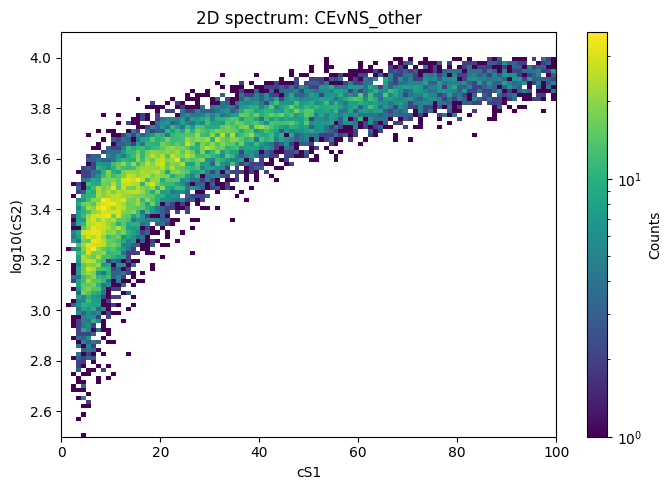

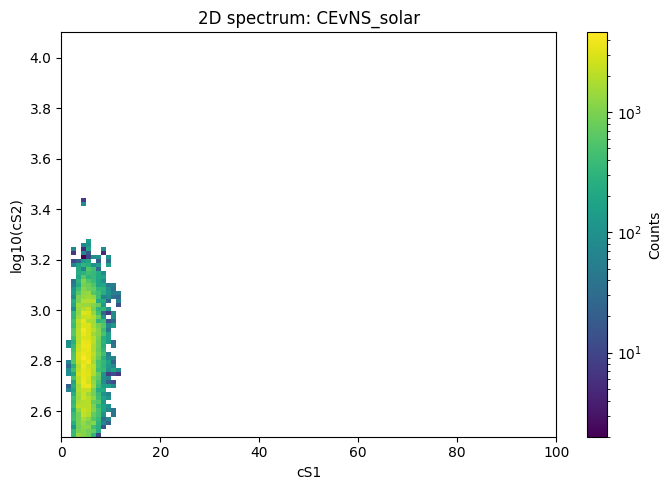

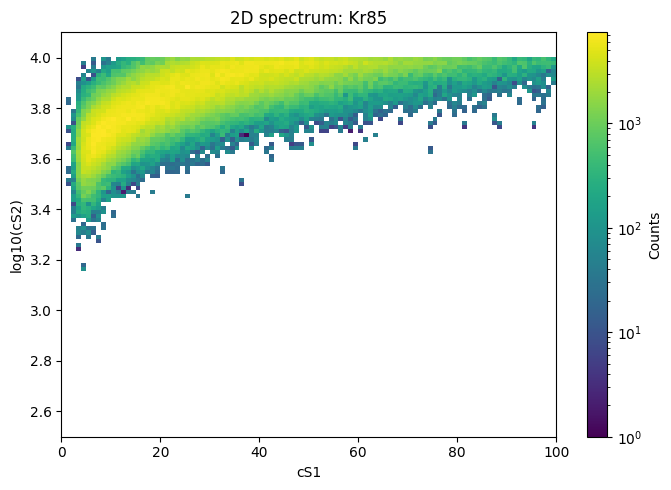

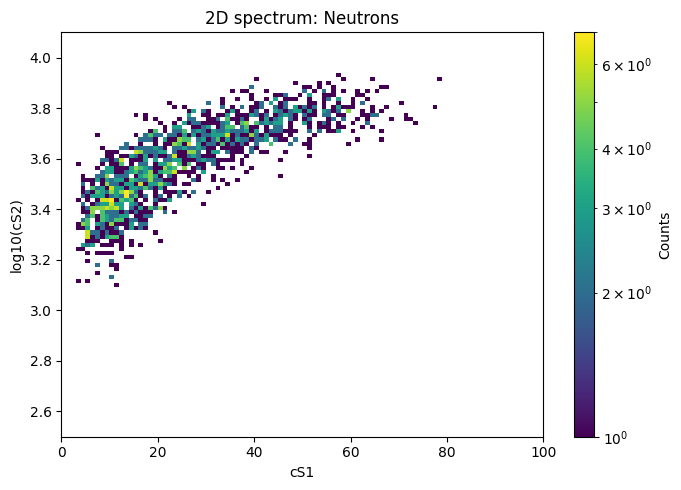

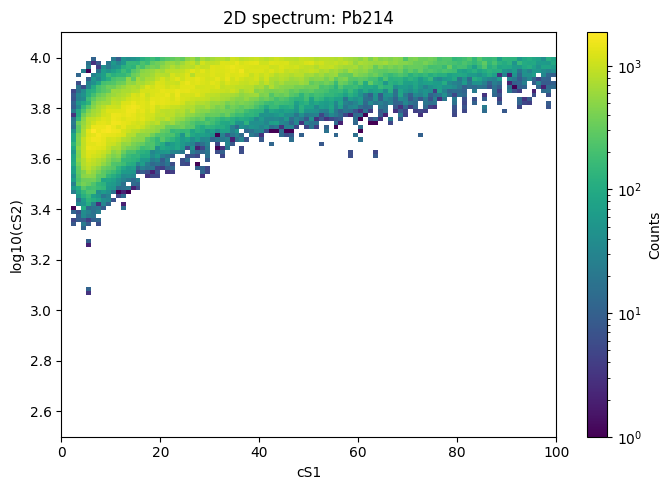

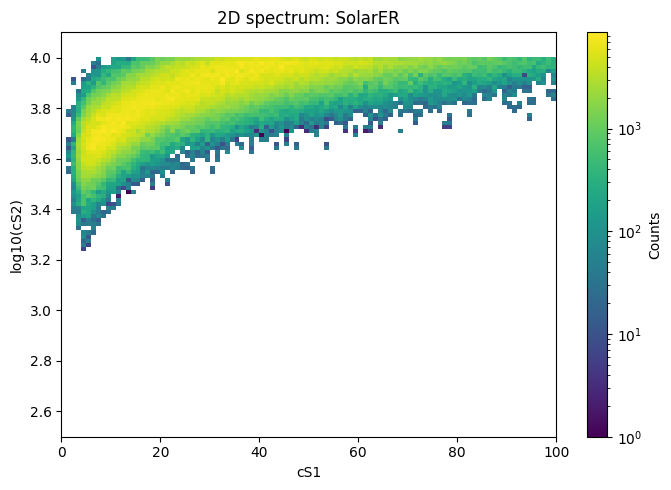

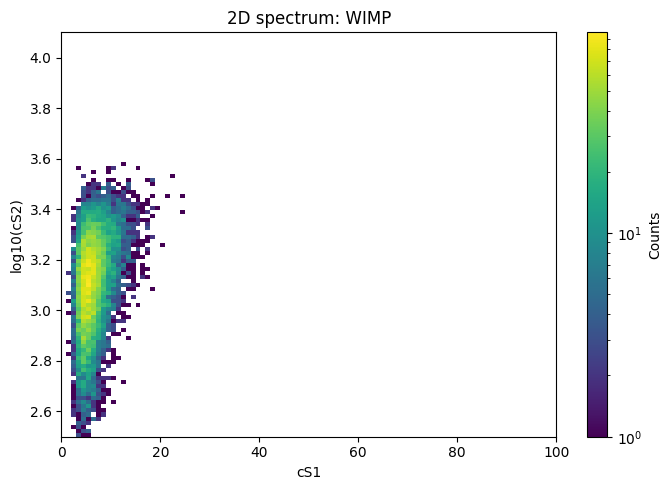

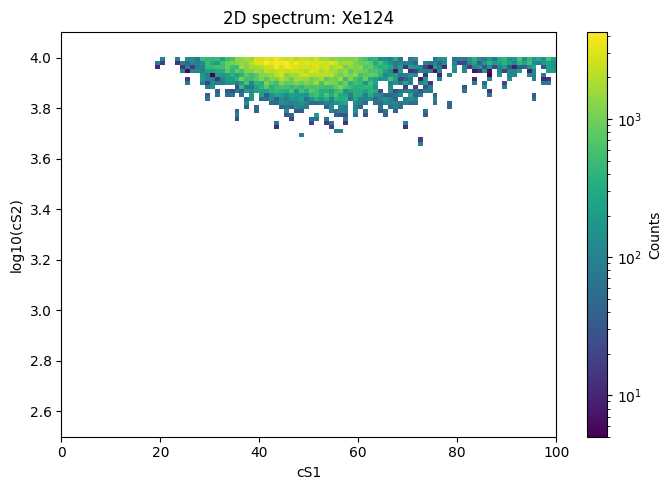

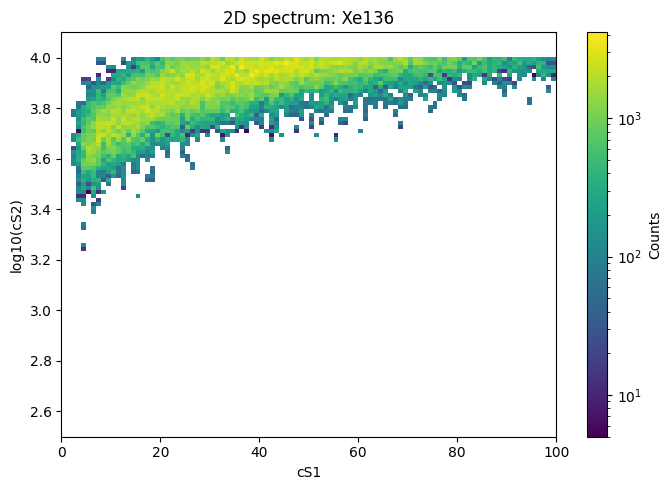

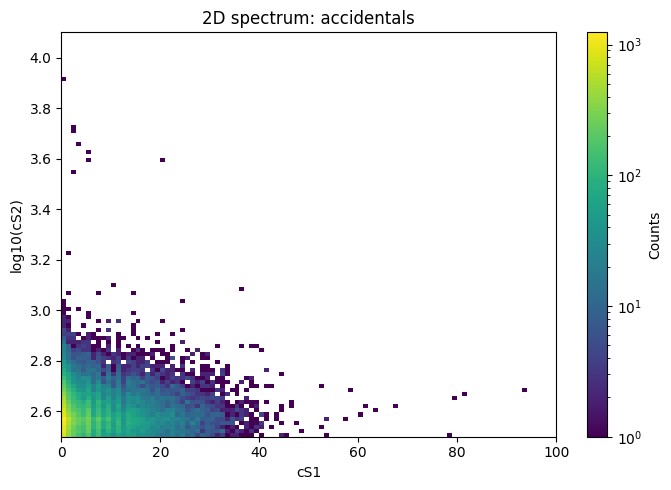

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Combine the list of DataFrames


import pandas as pd

flat_data = []

for mu, toy_list in data.items():
    for toy_df in toy_list:
        toy_df = toy_df.copy()
        toy_df["mu"] = mu
        flat_data.append(toy_df)

df = pd.concat(flat_data, ignore_index=True)




# df = pd.concat(data, ignore_index=True)

# Choose bins
s1_bins = np.linspace(0, 100, 101)
s2_bins = np.linspace(2.5, 4.1, 101)

for source, subdf in df.groupby("source"):
    H, xedges, yedges = np.histogram2d(
        subdf["cS1"],
        subdf["log10_cS2"],
        bins=[s1_bins, s2_bins]
    )

    plt.figure(figsize=(7, 5))

    pcm = plt.pcolormesh(
        xedges,
        yedges,
        np.ma.masked_less_equal(H.T, 0),
        norm=LogNorm(),
        shading="auto"
    )

    plt.colorbar(pcm, label="Counts")
    plt.xlabel("cS1")
    plt.ylabel("log10(cS2)")
    plt.title(f"2D spectrum: {source}")
    plt.tight_layout()
    plt.show()

### Sensitivity

In [8]:
with open('/global/cfs/cdirs/lz/users/rory_m/XLZD/FlameFitSimple/analyses/wimp_sensitivity/outputs/accidentals_200ty/toy_data_B.pkl', 'rb') as file:
    data = pickle.load(file)

print(len(data))
print(type(data))

1000
<class 'list'>


In [9]:
data[999]

,cS1,log10_cS2,radius,source
0,27.868469,3.980840,18035.056074,SolarER
1,79.149822,3.987458,7931.064611,Xe136
2,31.191759,3.893553,7352.560687,Xe136
3,4.002723,3.518096,11851.252583,Kr85
4,47.204318,3.998940,16606.203331,Kr85
...,...,...,...,...
6319,16.732308,3.826506,19804.641718,SolarER
6320,25.595192,3.981056,20920.603012,Kr85
6321,25.056979,3.872189,18216.120446,SolarER
6322,33.587819,3.954231,2249.834945,Xe136


In [10]:
data

[            cS1  log10_cS2        radius   source
 0      8.505966   3.608804  17398.234442    Xe136
 1     54.928038   3.989495  20213.960033  SolarER
 2     20.495606   3.926098  13918.647152    Xe136
 3     37.673440   3.849869  10267.760865     Kr85
 4     11.925181   3.654315  12166.834985    Xe136
 ...         ...        ...           ...      ...
 6221  26.210635   3.809351  19255.297456    Xe136
 6222  21.207876   3.980126  17740.348032     Kr85
 6223  15.270178   3.661975   1984.005779  SolarER
 6224  34.225327   3.986681  13319.623858     Kr85
 6225  55.698449   3.983799   7557.574219     Kr85
 
 [6226 rows x 4 columns],
             cS1  log10_cS2        radius   source
 0      7.529567   3.716389  10444.766760     Kr85
 1      7.435091   3.701599   6514.075636  SolarER
 2      6.697670   3.632598   1606.748567  SolarER
 3      7.200490   3.566475  12144.894201  SolarER
 4     47.142947   3.951383  20743.474249     Kr85
 ...         ...        ...           ...      ...
 63

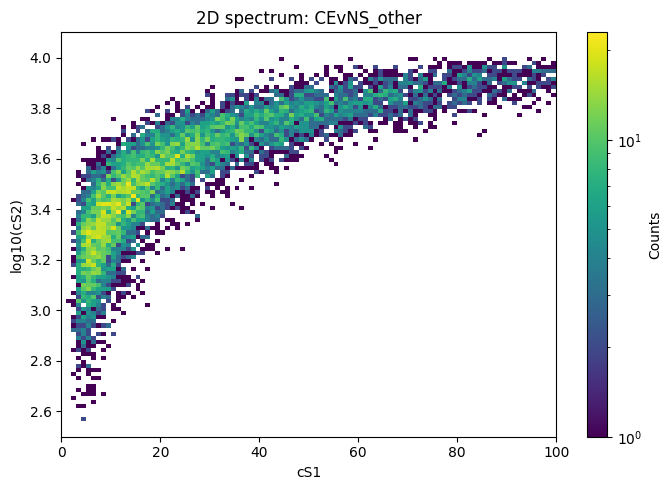

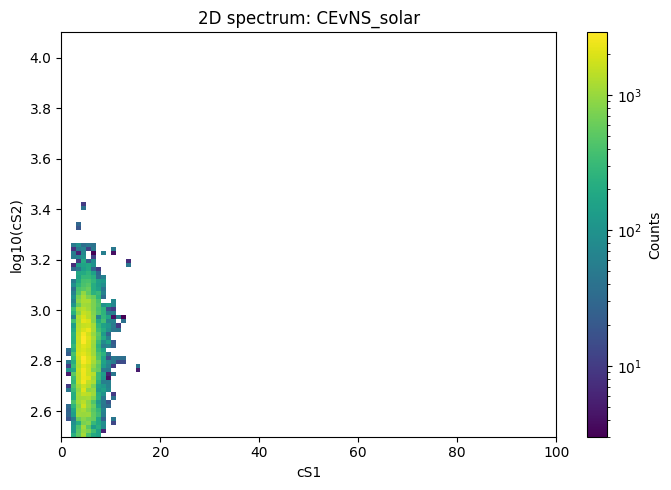

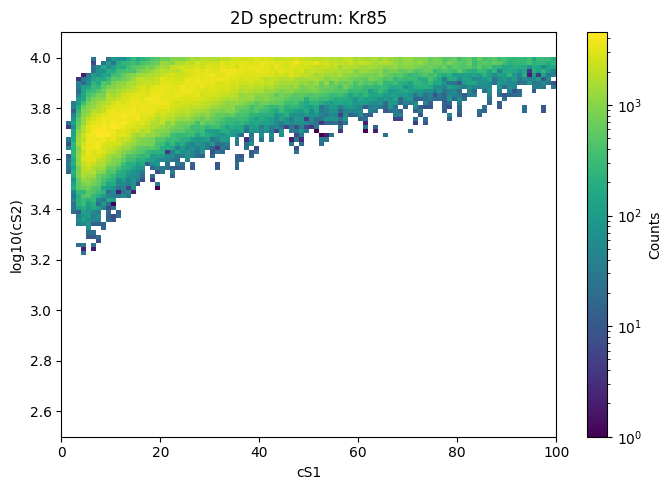

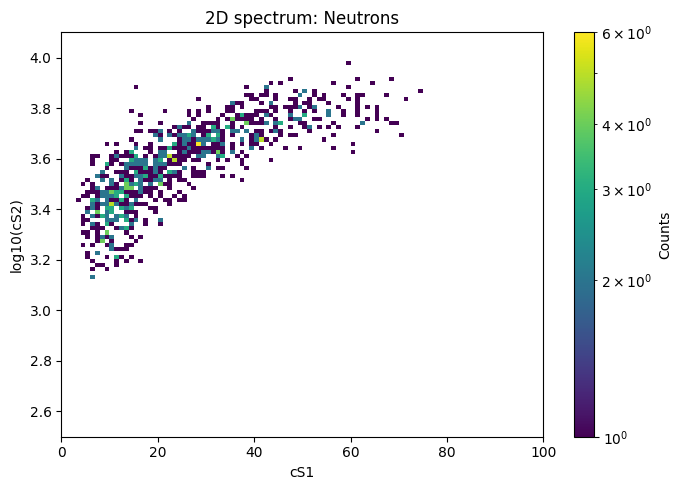

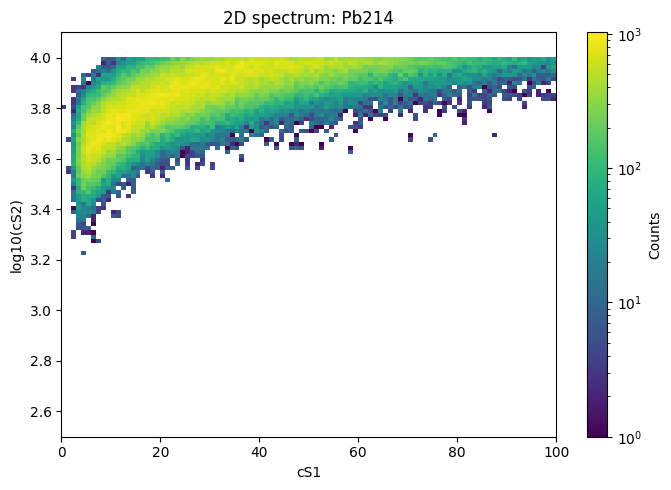

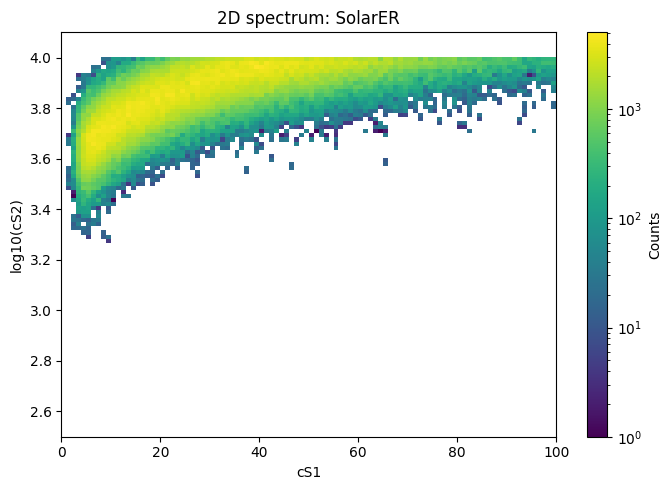

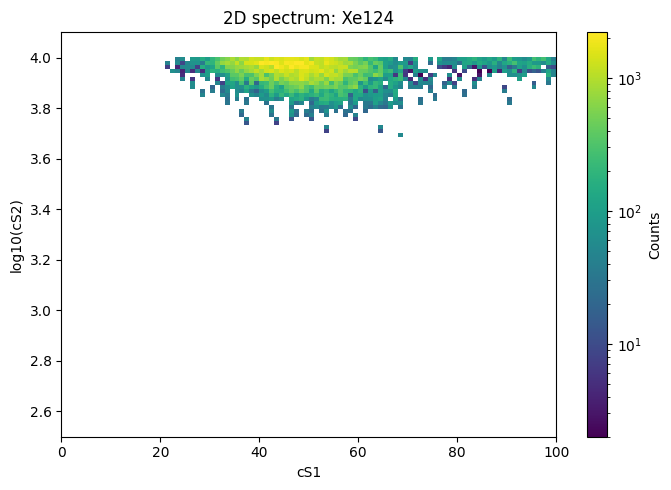

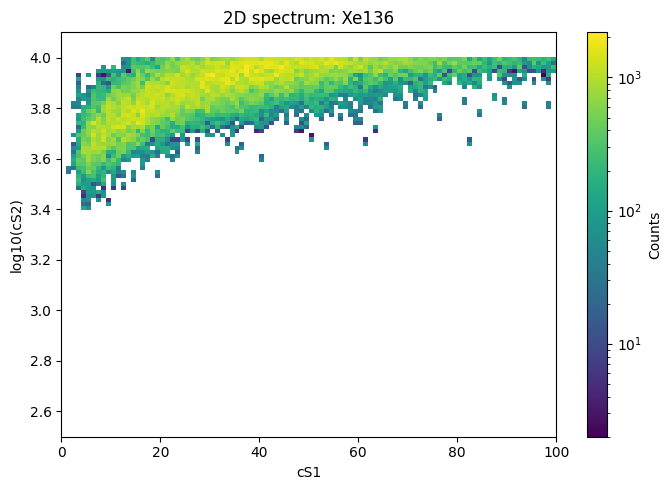

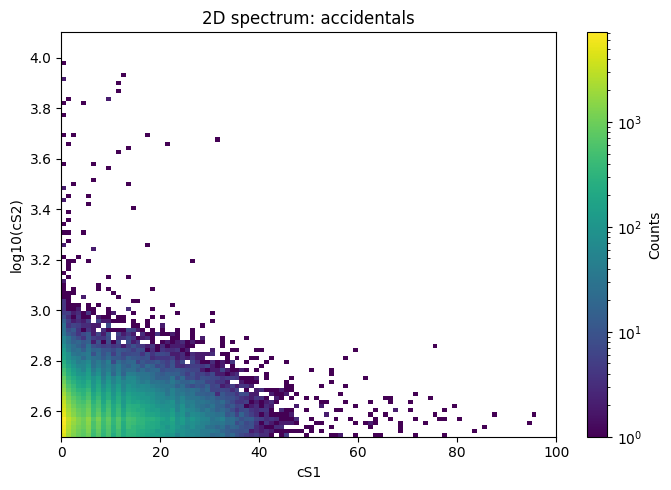

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Combine the list of DataFrames
df = pd.concat(data, ignore_index=True)

# Choose bins
s1_bins = np.linspace(0, 100, 101)
s2_bins = np.linspace(2.5, 4.1, 101)

for source, subdf in df.groupby("source"):
    H, xedges, yedges = np.histogram2d(
        subdf["cS1"],
        subdf["log10_cS2"],
        bins=[s1_bins, s2_bins]
    )

    plt.figure(figsize=(7, 5))

    pcm = plt.pcolormesh(
        xedges,
        yedges,
        np.ma.masked_less_equal(H.T, 0),
        norm=LogNorm(),
        shading="auto"
    )

    plt.colorbar(pcm, label="Counts")
    plt.xlabel("cS1")
    plt.ylabel("log10(cS2)")
    plt.title(f"2D spectrum: {source}")
    plt.tight_layout()
    plt.show()

No events for Accidentals


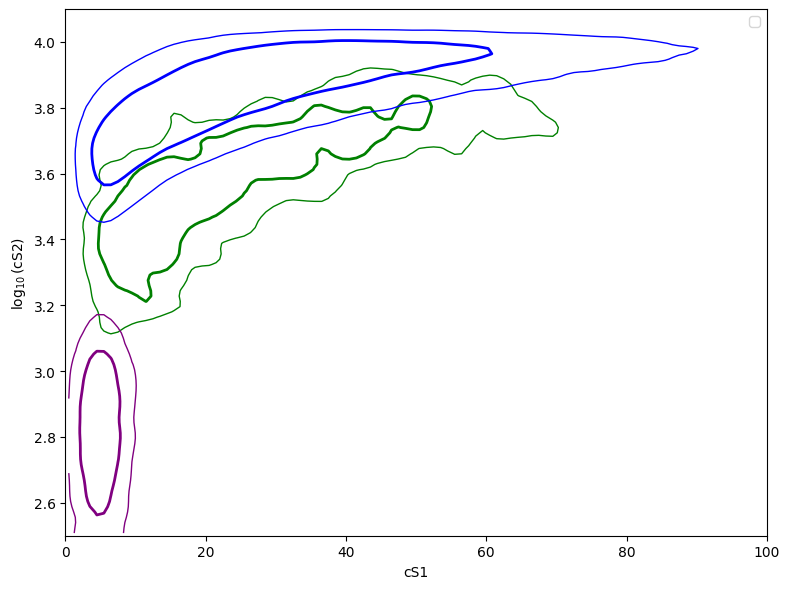

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

df = pd.concat(data, ignore_index=True)

sources_to_plot = [
    "Neutrons",
    "Accidentals",
    "CEvNS_solar",
    "SolarER"
]

colors = {
    "Neutrons": "green",
    "Accidentals": "orange",
    "CEvNS_solar": "purple",
    "SolarER": "blue",
}

def credible_levels(H, probs=(0.683, 0.954)):
    h = H.ravel()
    h = h[h > 0]

    h_sorted = np.sort(h)[::-1]
    cumsum = np.cumsum(h_sorted)
    cumsum /= cumsum[-1]

    levels = []
    for p in probs:
        idx = np.searchsorted(cumsum, p)
        levels.append(h_sorted[idx])

    return sorted(levels)

s1_bins = np.linspace(0, 100, 101)
s2_bins = np.linspace(2.5, 4.1, 101)

plt.figure(figsize=(8, 6))

for source in sources_to_plot:

    subdf = df[df["source"] == source]

    if len(subdf) == 0:
        print(f"No events for {source}")
        continue

    H, xedges, yedges = np.histogram2d(
        subdf["cS1"],
        subdf["log10_cS2"],
        bins=[s1_bins, s2_bins]
    )

    H = gaussian_filter(H.T, sigma=1.5)

    levels = credible_levels(H)

    X = 0.5 * (xedges[:-1] + xedges[1:])
    Y = 0.5 * (yedges[:-1] + yedges[1:])

    plt.contour(
        X,
        Y,
        H,
        levels=levels,
        colors=[colors[source]],
        linewidths=[1.0, 2.0]
    )

plt.xlabel("cS1")
plt.ylabel(r"$\log_{10}(\mathrm{cS2})$")
plt.xlim(0, 100)
plt.ylim(2.5, 4.1)
plt.legend(sources_to_plot)
plt.tight_layout()
plt.show()